<a href="https://colab.research.google.com/github/arizonaCameraLab/papers/blob/main/DenseHolographicMemories/DAMMno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scaling of grating modulation and efficiency
##David Brady
##University of Arizona
##written with Anthropic Fable 5.1
##Fall 2026

# Fig. 3: recording dynamic range and the recovery of $M^{-1}$ efficiency scaling

This cell reproduces Fig. 3 of *Dense holographic associative memories* (D. J. Brady and G. Nero). Sec. 3 of the paper argues that the $M^{-2}$ per-hologram efficiency of photorefractive media comes from two mechanisms, self-energy recording and illumination-locked erasure, and that a gradient-responsive cell with illumination-independent decay removes both. The figure asks what limit remains once they are gone. The answer is the finite index-modulation range of a single cell, and the simulation shows that this limit costs $M^{-1}$, or at worst a logarithmic factor more, rather than $M^{-2}$.

No device parameters enter; the result is a statement about the statistics of superposed gratings and is normalized to $M=1$.

## The model

Each stored association writes one grating into a cell. With $M$ associations superimposed, the index modulation along a line through the cell is

$$
\Delta n(x) \;=\; A \sum_{k=1}^{M} \sin\!\big(K_k x + \phi_k\big),
$$

with distinct spatial frequencies $K_k$ and phases $\phi_k$. In the one-hot architecture of Sec. 2 the phase of grating $k$ at a given cell is fixed by the optical path from reference focus $k$, and these paths differ from cell to cell in a way the designer does not control, so the $\phi_k$ are taken as independent uniform random variables.

The cell has a finite modulation range $|\Delta n| \le \Delta n_{\max}$. The largest per-grating amplitude $A$ it can hold depends on which measure of the total excursion is required to stay within that range, and the per-grating diffraction efficiency in the weak-grating regime is $\eta \propto A^2$. Three measures are relevant:

- **RMS.** For random phases the mean-square modulation adds incoherently, so $\Delta n_{\mathrm{rms}} = A\sqrt{M/2}$. A cell limited by average stored energy, or one that saturates softly, sizes $A$ to this and obtains $\eta \propto M^{-1}$.
- **Typical peak.** The maximum of $|\Delta n(x)|$ over the aperture is the maximum of a sum of $M$ random sinusoids and grows as $A\sqrt{M\log M}$. A cell that hard-clips at $\Delta n_{\max}$ sizes $A$ to this and obtains $\eta \propto (M\log M)^{-1}$.
- **Worst case.** If all $M$ phases aligned at some $x$ the peak would reach $A M$, giving $\eta \propto M^{-2}$. For distinct gratings with random phases this never occurs; it is a bound, not an operating point, and because it scales exactly as the photorefractive curve it is omitted from the plot.

The comparison curve is the best case for a photorefractive medium: an optimally equalized exposure schedule in which each of $M$ gratings ends with amplitude $\Delta n_{\max}/M$, so $\eta \propto M^{-2}$. This is the $M/\#$ scaling of Mok, Burr, and Psaltis.

## What the code does

`superposition_stats(M)` builds $\Delta n(x)$ on 8192 samples of one period with $K_k = 1,\dots,M$ and 200 independent phase draws, and returns the mean peak and mean RMS over the draws. `run_sweep` evaluates this for $M$ from 1 to 200 (22 log-spaced values), converts each excursion measure to an allowed amplitude $A = \Delta n_{\max}/\text{excursion}$, and squares it. All curves are normalized to their $M = 1$ value. The script prints the fitted log-log slopes over $M \ge 6$ as a check; expect

| quantity | fitted slope |
|---|---|
| RMS modulation | $+0.50$ |
| typical-peak modulation | $+0.61$ (between $\tfrac12$ and 1, consistent with $\sqrt{M\log M}$ over this range) |
| efficiency, RMS-limited | $-1.00$ |
| efficiency, hard-clip | $-1.22$ |
| efficiency, photorefractive | $-2.00$ |

## Reading the figure

Panel (a) shows how the total modulation grows: the RMS follows $\sqrt{M}$ exactly, and the typical peak sits above it by a slowly growing factor $\sim\sqrt{\log M}$, far below the linear worst case. Panel (b) converts this into efficiency. The RMS-limited differential cell lies on $M^{-1}$; the hard-clipping cell lies just below it, on $(M\log M)^{-1}$; the photorefractive medium lies on $M^{-2}$. The arrow at $M = 200$ marks the gap between the differential cell and the photorefractive medium, which grows in proportion to $M$ and is the factor separating demonstrated photorefractive memories from the $(L/\lambda_0)^3$ grating-count bound.

Dinc, Moser, and Psaltis (Opt. Lett. 2024) reached the $M^{-1}$ relation by computing the final index pattern digitally and printing it. The point of the paper is that a gradient-responsive cell with autonomous decay reaches it in situ, in the recording step itself.

## Scope

The superposition is one-dimensional with unit-spaced integer frequencies; the gratings actually stored occupy a two-dimensional region of transverse wavevector set by the input-cap and reference-line geometry of Sec. 2, which may change the constant in the $\sqrt{M\log M}$ law but not the exponent. $\Delta n_{\max}$ is a normalized ceiling, so the figure gives scaling, not an absolute capacity; turning it into a number for $M$ requires the per-cell $CV_{\max}$ and the modulation mechanism of Sec. 4, which are not yet demonstrated.

In [4]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

[fit] typical peak modulation vs M:  +0.61  (sqrt(M log M): between 0.5 and 1)
[fit] RMS modulation vs M:           +0.50  (expect +0.5)
[fit] differential, RMS-limited eta:   -1.00  (expect -1)
[fit] differential, hard-clip eta:     -1.22  (about -1, log-penalized)
[fit] differential, worst-case bound:  -2.00  (expect -2)
[fit] photorefractive, equalized eta:  -2.00  (expect -2)


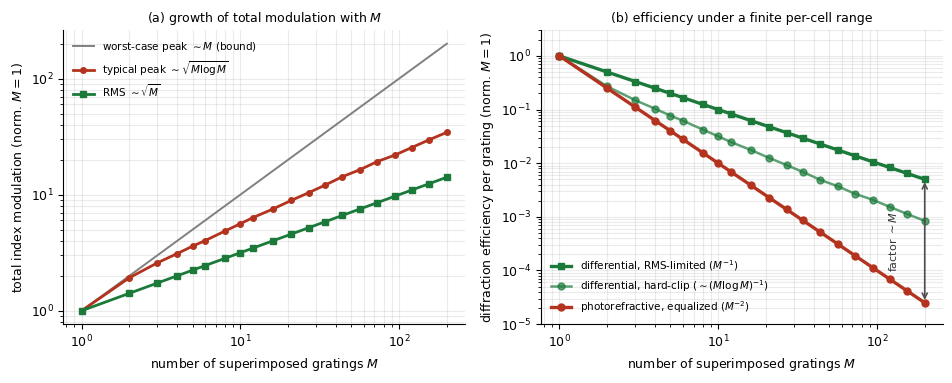

In [8]:



HERE = os.getcwd()
rng = np.random.default_rng(13)


def superposition_stats(M, n_x=8192, n_trials=200):
    """Mean typical-peak and mean RMS of Delta n(x) = sum_k sin(K_k x + phi_k)
    over n_trials random-phase draws."""
    x = np.linspace(0, 2*np.pi, n_x, endpoint=False)
    peaks = np.empty(n_trials); rmss = np.empty(n_trials)
    K = np.arange(1, M+1)
    for t in range(n_trials):
        phi = rng.uniform(0, 2*np.pi, M)
        dn = np.sin(K[:, None]*x[None, :] + phi[:, None]).sum(axis=0)
        peaks[t] = np.max(np.abs(dn)); rmss[t] = np.sqrt(np.mean(dn**2))
    return peaks.mean(), rmss.mean()


def run_sweep(M_values, dn_max=1.0):
    n = len(M_values)
    typ_peak = np.empty(n); rms = np.empty(n)
    for i, M in enumerate(M_values):
        typ_peak[i], rms[i] = superposition_stats(M)
    Mf = M_values.astype(float)
    worst_peak = Mf
    eta = lambda excursion: (dn_max/excursion)**2
    eta_pr = (dn_max/Mf)**2                      # photorefractive, equalized
    return (Mf, eta(typ_peak), eta(rms), eta(worst_peak), eta_pr,
            typ_peak, rms, worst_peak)


if __name__ == "__main__":
    M_values = np.unique(np.round(np.logspace(0, 2.3, 22)).astype(int))
    (Mf, eta_typ, eta_rms, eta_worst, eta_pr,
     typ_peak, rms, worst_peak) = run_sweep(M_values)
    norm = lambda c: c/c[0]
    mask = M_values >= 6
    fit = lambda c: np.polyfit(np.log(Mf[mask]), np.log(norm(c)[mask]), 1)[0]
    print(f"[fit] typical peak modulation vs M:  {fit(typ_peak):+.2f}  (sqrt(M log M): between 0.5 and 1)")
    print(f"[fit] RMS modulation vs M:           {fit(rms):+.2f}  (expect +0.5)")
    print(f"[fit] differential, RMS-limited eta:   {fit(eta_rms):.2f}  (expect -1)")
    print(f"[fit] differential, hard-clip eta:     {fit(eta_typ):.2f}  (about -1, log-penalized)")
    print(f"[fit] differential, worst-case bound:  {fit(eta_worst):.2f}  (expect -2)")
    print(f"[fit] photorefractive, equalized eta:  {fit(eta_pr):.2f}  (expect -2)")

    plt.rcParams.update({"font.size": 9, "axes.titlesize": 9})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 3.9))

    # (a) modulation measures
    ax1.loglog(Mf, norm(worst_peak), "-", color="0.5", lw=1.4, label=r"worst-case peak $\sim M$ (bound)")
    ax1.loglog(Mf, norm(typ_peak), "o-", color="#b3331e", lw=2, ms=4, label=r"typical peak $\sim\sqrt{M\log M}$")
    ax1.loglog(Mf, norm(rms), "s-", color="#1b7a3a", lw=2, ms=4, label=r"RMS $\sim\sqrt{M}$")
    ax1.set_xlabel("number of superimposed gratings $M$")
    ax1.set_ylabel("total index modulation (norm. $M{=}1$)")
    ax1.set_title("(a) growth of total modulation with $M$")
    ax1.legend(fontsize=7.5, loc="upper left", frameon=False)
    ax1.grid(True, which="both", alpha=0.25)

    # (b) efficiency
    ax2.loglog(Mf, norm(eta_rms), "s-", color="#1b7a3a", lw=2.4, ms=5, label=r"differential, RMS-limited ($M^{-1}$)")
    ax2.loglog(Mf, norm(eta_typ), "o-", color="#1b7a3a", lw=1.8, ms=5, alpha=0.7, label=r"differential, hard-clip ($\sim(M\log M)^{-1}$)")
    #ax2.loglog(Mf, norm(eta_worst), "v:", color="#1b7a3a", lw=1.3, ms=4, alpha=0.45, label=r"differential, worst-case bound ($M^{-2}$)")
    ax2.loglog(Mf, norm(eta_pr), "o-", color="#b3331e", lw=2.4, ms=5, label=r"photorefractive, equalized ($M^{-2}$)")
    ax2.set_xlabel("number of superimposed gratings $M$")
    ax2.set_ylabel("diffraction efficiency per grating (norm. $M{=}1$)")
    ax2.set_title("(b) efficiency under a finite per-cell range")
    ax2.legend(fontsize=7.5, loc="lower left", frameon=False)
    ax2.grid(True, which="both", alpha=0.25)
    ax2.set_ylim(1e-5, 3)
    ax2.annotate("", xy=(Mf[-1], norm(eta_rms)[-1]), xytext=(Mf[-1], norm(eta_pr)[-1]),
                 arrowprops=dict(arrowstyle="<->", color="0.3", lw=1.2))
    ax2.text(Mf[-1]*0.58, np.sqrt(norm(eta_rms)[-1]*norm(eta_pr)[-1]), r"factor $\sim M$",
             fontsize=8, color="0.2", rotation=90, va="center")

    for a in (ax1, ax2):
        a.spines["top"].set_visible(False); a.spines["right"].set_visible(False)
    fig.tight_layout()
    plt.show()


    fig.savefig(os.path.join(HERE, "sim3_scaling.pdf"), bbox_inches="tight")
    #fig.savefig(os.path.join(HERE, "sim3_scaling.png"), bbox_inches="tight", dpi=150)
